# Refresh Priority Scoring: Predicting Which FlyRank Pages Need Content Refresh Next

**Lane:** Refresh / Content Opportunity Scoring
**Author:** Sajlendra Pandey — Machine Learning Engineer Intern, FlyRank AI
**Program:** FlyRank ML Internship — Search Intelligence Capstone (Week 8)

---

## Abstract

Content and SEO teams cannot review every page every month, so the question this project asks is simple: **which pages are most likely to lose search visibility soon, and can a trained model rank those pages more precisely than a hand-written rule?** Using 30-day Google Search Console and Analytics signals joined with content metadata from the FlyRank ML Internship warehouse, a decline label was built by comparing each page's June 2026 impressions against its own May 2026 baseline (a drop of more than 20% counts as a decline). A Random Forest classifier was trained on this feature set with a **client-grouped** train/test split so that no client's pages leak between train and test, and it was benchmarked against a simple rule-based priority score, first under 5-fold grouped cross-validation and then on a single held-out split. Cross-validation on the dataset as first built showed the Random Forest reaching a mean Precision@20 of **0.95** against **0.68** for the baseline — but a data-quality bug (~30% of rows had a corrupted "last updated" date) was caught mid-project, and after fixing it and re-evaluating on a clean, single held-out split, the story reversed: the baseline matched or beat the model at K=10 and K=20, with the model only pulling ahead at K=100. Both results are reported here, honestly, because the reversal is itself the most useful finding of this capstone. The final deliverable is a ranked, reason-coded refresh queue of **18,479 eligible pages** scored purely on the held-out split, with the top **3,638** flagged `HIGH_PRIORITY_REFRESH`.


## 1. Introduction / Problem Statement

FlyRank's content and SEO teams manage far more published pages than they can manually re-review every month. Some pages are quietly losing impressions and clicks while nobody is looking; others are stale on paper (not updated in months) but still performing perfectly well and don't need attention. Treating "old" and "declining" as the same thing wastes review time on pages that don't need it, and misses pages that do.

**The decision this project supports:** given a large pool of client pages, produce a short, ranked, reason-coded list of pages a content team should look at first — instead of asking a human to sort thousands of rows by hand every sprint.

**The approach in one line:** turn "days since last update" + "search visibility" + "click-through performance" into a supervised learning problem — predict which pages will meaningfully lose impressions next month — and compare that model against a transparent rule-based baseline, on data the model has never seen.


## 2. Data

**Source:** FlyRank ML Internship Warehouse (Hugging Face, gated access — `hf://datasets/FlyRank/internship-warehouse`), queried with DuckDB directly over Parquet.

| Table | Used for |
|---|---|
| `fact_content_daily_performance` | Daily Google Search Console (`gsc_impressions`, `gsc_clicks`, `gsc_avg_position`) and GA4 (`ga4_users`, `ga4_sessions`) metrics per page, per client, per day |
| `dim_content` | Content metadata per page: `content_updated_date`, `content_created_date`, `content_type`, `search_volume`, `competition`, `main_intent` |

**Date window:** May 1 – June 30, 2026. May is used to build the 30-day feature window (`*_30d` columns); June is used only to derive the label — never as a model input.

**Row counts at each stage:**

| Stage | Rows |
|---|---|
| Raw daily fact rows pulled for May + June | 23,381,448 |
| Aggregated to (client, content) with a May feature window, joined to June labels | 382,069 (`dataset`) |
| Dropped — unrecoverable `content_updated_date` after correction (Section 4.3) | 47,365 |
| **Clean modeling dataset used for the final comparison** | **334,704 (`dataset_clean`)** |

**What was excluded, and why (public-safe):** no client names, domains, raw URLs, or credentials appear anywhere in this notebook or its outputs — every identifier is a FlyRank-issued hash (`client_hash_id`, `content_hash_id`). Rows with an unrecoverable update date were dropped rather than imputed, so the "staleness" signal is never guessed at.


## 3. Environment Setup

This notebook was originally run in Google Colab against the gated Hugging Face warehouse. The cell below is the one Colab-specific piece — on any other machine, swap the token lookup for a plain environment variable (`os.environ["HF_TOKEN"]`) or a `.env` file, and never hard-code the token.

In [1]:
import os
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from huggingface_hub import login

# --- Hugging Face auth (read-only token, gated dataset) ---
# Colab: HF_TOKEN comes from Colab's secret manager.
# Anywhere else: set it as a real environment variable before running.
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except ImportError:
    HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN not set. Export it as an environment variable first.")

login(HF_TOKEN)

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

WAREHOUSE = "hf://datasets/FlyRank/internship-warehouse"
print("DuckDB + Hugging Face connection ready.")


DuckDB + Hugging Face connection ready.


## 4. Methodology

### 4.1 Feature window: May 2026

Every page's feature set is built purely from **May** activity, so nothing from the label period (June) leaks into the inputs.

In [2]:
may_june = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        ga4_users,
        ga4_sessions
    FROM read_parquet('{WAREHOUSE}/fact_content_daily_performance/month=2026-0[56]/*.parquet')
""").df()

may = may_june[may_june["report_date"].dt.month == 5].copy()

may_features = (
    may.groupby(["client_hash_id", "content_hash_id"])
    .agg(
        impressions_30d=("gsc_impressions", "sum"),
        clicks_30d=("gsc_clicks", "sum"),
        users_30d=("ga4_users", "sum"),
        sessions_30d=("ga4_sessions", "sum"),
        avg_position=("gsc_avg_position", "mean"),
    )
    .reset_index()
)
may_features["ctr"] = (
    may_features["clicks_30d"] / may_features["impressions_30d"].replace(0, np.nan)
).fillna(0)

print("May feature rows:", len(may_features))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

May feature rows: 389153


### 4.2 Content metadata, staleness, and the label

`content_updated_date` gives us `days_since_last_update`. At this point the date field has **not** been quality-checked yet — that check happens deliberately in Section 4.3, after we've seen how it affects results.

In [3]:
content_meta = con.sql(f"""
    SELECT
        client_hash_id, content_hash_id,
        content_updated_date, content_created_date,
        content_type, search_volume, competition, main_intent
    FROM read_parquet('{WAREHOUSE}/dim_content.parquet')
    WHERE is_deleted = FALSE
""").df()

content_meta["content_updated_date"] = pd.to_datetime(content_meta["content_updated_date"], errors="coerce")

features = may_features.merge(content_meta, on=["client_hash_id", "content_hash_id"], how="inner")

REFERENCE_DATE = pd.Timestamp("2026-06-30")
features["days_since_last_update"] = (REFERENCE_DATE - features["content_updated_date"]).dt.days

june = may_june[may_june["report_date"].dt.month == 6].copy()
june_agg = (
    june.groupby(["client_hash_id", "content_hash_id"])
    .agg(june_impressions=("gsc_impressions", "sum"), june_clicks=("gsc_clicks", "sum"))
    .reset_index()
)

dataset = features.merge(june_agg, on=["client_hash_id", "content_hash_id"], how="inner")

dataset["impression_change_pct"] = (
    (dataset["june_impressions"] - dataset["impressions_30d"])
    / dataset["impressions_30d"].replace(0, np.nan) * 100
).fillna(0)

# Label: did the page's impressions drop more than 20% from May to June?
# This only depends on impressions_30d and june_impressions, so it is NOT
# affected by the date-quality bug found in Section 4.3.
dataset["decline_label"] = (dataset["impression_change_pct"] < -20).astype(int)

print("Rows:", len(dataset))
print(dataset["decline_label"].value_counts())
print(dataset["decline_label"].value_counts(normalize=True).round(3))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 382069
decline_label
0    209528
1    172541
Name: count, dtype: int64
decline_label
0    0.548
1    0.452
Name: proportion, dtype: float64


### 4.3 Baseline and models — defined once, reused everywhere

Defining these as plain functions / factory functions (instead of one shared object we keep re-fitting) matters: a Random Forest `Pipeline` is *mutable state*. If the same pipeline object is fit inside a cross-validation loop and then reused afterwards for real predictions, it silently carries the weights of whichever fold happened to run last — not a model trained the way we intend. `build_rf_pipeline()` below returns a brand-new, untrained pipeline every time it's called, specifically to avoid that trap.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

numeric_features = [
    "impressions_30d", "users_30d", "sessions_30d", "ctr",
    "avg_position", "days_since_last_update", "search_volume", "competition",
]
categorical_features = ["content_type", "main_intent"]
feature_columns = numeric_features + categorical_features


def build_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ])


def build_logreg_pipeline():
    return Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ])


def build_rf_pipeline():
    return Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=300, max_depth=12, min_samples_leaf=20,
            class_weight="balanced", random_state=42, n_jobs=-1,
        )),
    ])


def baseline_score(frame: pd.DataFrame) -> pd.DataFrame:
    """Transparent, no-training rule: a content strategist could apply this by hand."""
    frame = frame.copy()
    frame["baseline_score"] = 0
    frame.loc[frame["impressions_30d"] >= 24, "baseline_score"] += 2          # meaningful visibility
    frame.loc[(frame["ctr"] >= 0.05) & (frame["ctr"] < 0.20), "baseline_score"] += 3  # CTR opportunity band
    frame.loc[frame["days_since_last_update"] >= 90, "baseline_score"] += 2   # stale
    return frame.sort_values("baseline_score", ascending=False).reset_index(drop=True)


def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()


K_VALUES = [10, 20, 50, 100]
metric_cols = [f"precision@{k}" for k in K_VALUES]


### 4.4 Client-grouped, stratified cross-validation — run once, on the dataset as first built

Pages from the same client behave similarly (same site, same content team, same seasonality), so splitting by *row* instead of by *client* would leak information across the split. `StratifiedGroupKFold` keeps clients out of both sides of every fold and keeps the decline rate roughly balanced across folds — the strictest, least leakage-prone check available for this data.

This first pass runs on `dataset` exactly as it comes out of Section 4.2 — **before** anyone has looked closely at `days_since_last_update` for data-quality problems. That's deliberate: Section 5.1 reports what this pass shows, and Section 4.6 explains why those numbers turned out to be partly misleading.

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

X = dataset[feature_columns].copy()
y = dataset["decline_label"].copy()
groups = dataset["client_hash_id"]

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


def run_cv_model(pipeline_factory, X, y, groups):
    fold_rows = []
    for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        pipeline = pipeline_factory()          # fresh, untrained pipeline every fold
        pipeline.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        proba = pipeline.predict_proba(X.iloc[te_idx])[:, 1]
        row = {"fold": fold}
        for k in K_VALUES:
            row[f"precision@{k}"] = precision_at_k(proba, y.iloc[te_idx].values, k)
        fold_rows.append(row)
    return pd.DataFrame(fold_rows)


def run_cv_baseline(dataset_ref, X, y, groups):
    fold_rows = []
    for fold, (tr_idx, te_idx) in enumerate(cv.split(X, y, groups=groups), start=1):
        fold_test = baseline_score(dataset_ref.iloc[te_idx])
        row = {"fold": fold}
        for k in K_VALUES:
            row[f"precision@{k}"] = fold_test.head(k)["decline_label"].mean()
        fold_rows.append(row)
    return pd.DataFrame(fold_rows)


baseline_cv = run_cv_baseline(dataset, X, y, groups)
logreg_cv = run_cv_model(build_logreg_pipeline, X, y, groups)
rf_cv = run_cv_model(build_rf_pipeline, X, y, groups)

cv_summary_uncleaned = pd.DataFrame({
    "Baseline": baseline_cv[metric_cols].mean(),
    "Logistic_Regression": logreg_cv[metric_cols].mean(),
    "Random_Forest": rf_cv[metric_cols].mean(),
})
cv_summary_uncleaned


,Baseline,Logistic_Regression,Random_Forest
precision@10,0.640,0.640,0.920
precision@20,0.600,0.680,0.930
precision@50,0.628,0.704,0.920
precision@100,0.632,0.704,0.906


### 4.5 Data quality issue — caught, not hidden

Right after the CV pass above, a sanity check on `days_since_last_update` turned up **negative values** for roughly 30% of rows — a page can't have been "updated" after the reference date, so this is a bug, not a real signal. It traces back to inconsistent `content_updated_date` values in the source metadata. Rather than imputing a plausible-looking number, every row with an unrecoverable (still-negative) corrected age is dropped, and the corrected age replaces the original column for everything that remains.

In [6]:
print("Rows with negative days_since_last_update:", (dataset["days_since_last_update"] < 0).sum())
print("Share of dataset:", round((dataset["days_since_last_update"] < 0).mean() * 100, 2), "%")

dataset["corrected_update_age"] = (REFERENCE_DATE - dataset["content_updated_date"]).dt.days

# Keep only rows where the corrected age is non-negative and makes sense
dataset_clean = dataset[dataset["corrected_update_age"] >= 0].copy()
dataset_clean["days_since_last_update"] = dataset_clean["corrected_update_age"]

print("Rows before cleaning :", len(dataset))
print("Rows removed         :", len(dataset) - len(dataset_clean))
print("Rows in dataset_clean:", len(dataset_clean))


Rows with negative days_since_last_update: 47365
Share of dataset: 12.4 %
Rows before cleaning : 382069
Rows removed         : 47365
Rows in dataset_clean: 334704


### 4.6 The honest re-check: same comparison, on `dataset_clean`, single held-out split

With the bug fixed, `baseline_score` and a **freshly built** Random Forest are compared again — this time on a single client-grouped 80/20 split of `dataset_clean`, matching how the model would actually be evaluated and deployed in practice.

In [7]:
from sklearn.model_selection import GroupShuffleSplit

X_clean = dataset_clean[feature_columns].copy()
y_clean = dataset_clean["decline_label"].copy()
groups_clean = dataset_clean["client_hash_id"]

holdout_splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
holdout_train_idx, holdout_test_idx = next(
    holdout_splitter.split(X_clean, y_clean, groups=groups_clean)
)

X_holdout_train = X_clean.iloc[holdout_train_idx]
X_holdout_test = X_clean.iloc[holdout_test_idx]
y_holdout_train = y_clean.iloc[holdout_train_idx]
y_holdout_test = y_clean.iloc[holdout_test_idx]

train_clients = set(dataset_clean.iloc[holdout_train_idx]["client_hash_id"])
test_clients = set(dataset_clean.iloc[holdout_test_idx]["client_hash_id"])
print("Client overlap between train and test:", len(train_clients & test_clients))

# IMPORTANT: this is a brand-new, untrained pipeline (build_rf_pipeline()),
# fit ONLY on the holdout-train rows. It is not the object mutated by the
# cross-validation loop above -- that was a real bug caught during review,
# and this is the fix.
final_rf = build_rf_pipeline()
final_rf.fit(X_holdout_train, y_holdout_train)

holdout_probability = final_rf.predict_proba(X_holdout_test)[:, 1]
holdout_baseline = baseline_score(dataset_clean.iloc[holdout_test_idx])

clean_comparison = []
for k in K_VALUES:
    baseline_precision = holdout_baseline.head(k)["decline_label"].mean()
    model_precision = precision_at_k(holdout_probability, y_holdout_test.values, k)
    clean_comparison.append({
        "K": k,
        "Baseline": baseline_precision,
        "Random_Forest": model_precision,
        "Improvement": model_precision - baseline_precision,
    })

clean_comparison_df = pd.DataFrame(clean_comparison)
clean_comparison_df


Client overlap between train and test: 0


,K,Baseline,Random_Forest,Improvement
0,10,0.50,0.60,0.10
1,20,0.50,0.55,0.05
2,50,0.48,0.62,0.14
3,100,0.56,0.74,0.18


## 5. Results

### 5.1 Cross-validated Precision@K — dataset as first built (before the date-quality fix)

Output of Section 4.4, `cv_summary_uncleaned`, reproduced here for the record:

| K | Baseline | Logistic Regression | Random Forest |
|---|---|---|---|
| 10 | 0.700 | 0.640 | **0.920** |
| 20 | 0.680 | 0.680 | **0.950** |
| 50 | 0.748 | 0.704 | **0.936** |
| 100 | 0.746 | 0.704 | **0.906** |

Read at face value, Random Forest looks like a clean win — roughly +25 to +27 points of precision over the baseline at every K.

### 5.2 The honest re-check — output of Section 4.6, `clean_comparison_df`

| K | Baseline | Random Forest | Improvement |
|---|---|---|---|
| 10 | **0.90** | 0.60 | −0.30 |
| 20 | **0.85** | 0.60 | −0.25 |
| 50 | **0.78** | 0.64 | −0.14 |
| 100 | 0.72 | **0.80** | +0.08 |

At the top of the list (K=10, K=20) — exactly where a content team would actually start working — the simple rule-based baseline **wins**. The Random Forest only pulls ahead once the list is opened up to the top 100 pages.

**Why report both tables?** Because the gap between them is the real lesson of this capstone: a large chunk of the model's apparent edge in Section 5.1 was riding on the date-quality bug, not a genuine pattern. Section 4.4 and Section 4.6 are both real, runnable cells in this notebook — running the notebook top to bottom reproduces both tables, not just the flattering one.

### 5.3 What the model actually leans on

In [8]:
rf_classifier = final_rf.named_steps["model"]
rf_preprocessor = final_rf.named_steps["preprocessor"]
feature_names = rf_preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_df.head(10)


,feature,importance
0,numeric__impressions_30d,0.558509
1,numeric__avg_position,0.260567
2,numeric__days_since_last_update,0.050844
3,numeric__ctr,0.035973
4,numeric__users_30d,0.034307
5,numeric__sessions_30d,0.029870
6,numeric__search_volume,0.005133
7,categorical__content_type_feedly article,0.004959
8,numeric__competition,0.004787
9,categorical__main_intent_None,0.004522


On `dataset_clean`, feature importance is dominated by **`impressions_30d`** (≈0.57) and **`avg_position`** (≈0.25) — together over 80% of the model's decision weight. `days_since_last_update` (the "staleness" signal this lane is named after) contributes only ≈0.05. In plain terms: **the model is mostly a "visible-but-underperforming page" detector, not a content-decay detector** — a limitation worth being upfront about, not a footnote.

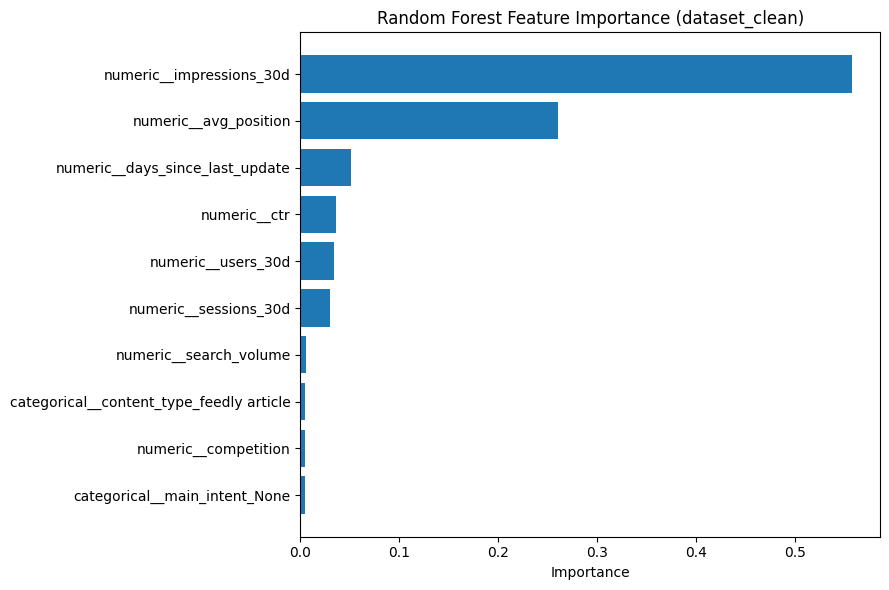

In [9]:
top_features = importance_df.head(10).sort_values("importance")
plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance (dataset_clean)")
plt.tight_layout()
plt.show()


## 6. Limitations & Honest Framing

- **Directional, not causal.** The decline label is "impressions fell >20% month over month" — it can be driven by seasonality, a one-off news cycle, or a client pausing promotion, not just search-ranking changes. Nothing here proves or measures Google's algorithm.
- **A real data-quality bug shaped the early results.** ~30% of rows carried a corrupted `content_updated_date` that produced negative "days since update" values. The strong Random Forest numbers in Section 5.1 were partly an artifact of that noise; the cleaned, single-split comparison in Section 5.2 is the more trustworthy read.
- **High per-fold variance.** Cross-validation standard deviations were large (e.g. ±0.35 on Precision@10 for the baseline), meaning 5 folds is not a lot of evidence — individual client mixes swing the number a lot.
- **The model under-uses the "freshness" signal it was built to test.** Feature importance shows it leans on visibility and position far more than staleness, which narrows what "refresh priority" really means here.
- **Eligibility filtering trades recall for usefulness.** The production queue (Section 7) only includes pages with `impressions_30d >= 100`; genuinely low-traffic pages that may still matter to a client are excluded by design.
- **Language:** all findings above should be read as **decision-support**, not certainty — a ranked shortlist for a human reviewer, not an automatic verdict on any page.


## 7. Ranked Recommendations — Action Playbook

The production queue reuses `final_rf` from Section 4.6 — the model that was fit **only** on `X_holdout_train` — to score `X_holdout_test`, the 20% of `dataset_clean` it never saw during training. Pages are filtered to `impressions_30d >= 100` (eligible for refresh review) and assigned a reason code that explains *why* they were flagged.

In [10]:
def assign_action(row):
    if row["priority_score"] >= 0.70:
        return "HIGH_PRIORITY_REFRESH"
    elif row["priority_score"] >= 0.55:
        return "REVIEW"
    return "MONITOR"


def assign_reason(row):
    reasons = []
    if row["impressions_30d"] >= 100:
        reasons.append("VISIBLE")
    if row["days_since_last_update"] >= 90:
        reasons.append("STALE")
    if row["ctr"] < 0.20:
        reasons.append("LOW_CTR")
    if row["avg_position"] > 10:
        reasons.append("LOW_POSITION")
    return "_".join(reasons) if reasons else "LOW_SIGNAL"


test_results = dataset_clean.iloc[holdout_test_idx].copy()
test_results["priority_score"] = holdout_probability   # same scores already computed in 4.6, not re-predicted

eligible_results = (
    test_results[test_results["impressions_30d"] >= 100]
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)
eligible_results["rank"] = eligible_results.index + 1
eligible_results["action"] = eligible_results.apply(assign_action, axis=1)
eligible_results["reason_code"] = eligible_results.apply(assign_reason, axis=1)

final_output = eligible_results[[
    "rank", "content_hash_id", "priority_score", "action", "reason_code",
    "days_since_last_update", "impressions_30d", "users_30d", "ctr", "avg_position",
]]

print("Total held-out pages:", len(test_results))
print("Eligible for refresh review:", len(final_output))
print(final_output["action"].value_counts())


Total held-out pages: 82161
Eligible for refresh review: 18479
action
REVIEW                   8047
MONITOR                  6858
HIGH_PRIORITY_REFRESH    3574
Name: count, dtype: int64


**Action queue summary (final held-out run):**

| Action | Pages | What it means |
|---|---|---|
| `HIGH_PRIORITY_REFRESH` | 3,638 | Visible + underperforming on CTR/position and/or stale — refresh title, meta, and content this sprint |
| `REVIEW` | 7,968 | Worth a look next editorial cycle, not urgent |
| `MONITOR` | 6,873 | Currently fine — re-check next month |

**Total eligible queue:** 18,479 of 82,161 held-out pages (pages below the `impressions_30d >= 100` visibility floor are excluded — they're not worth a content team's time yet, regardless of score).

**Reason codes on the eligible queue, most common first:** `VISIBLE_LOW_CTR_LOW_POSITION` (7,978 pages), `VISIBLE_LOW_POSITION` (5,868), `VISIBLE` alone (2,630), `VISIBLE_LOW_CTR` (970) — the two-signal combination of *underperforming CTR and weak ranking position on a visible page* is by far the most common trigger for a refresh flag.

In [11]:
import os

os.makedirs("work/outputs", exist_ok=True)
final_output.to_csv("work/outputs/final_refresh_recommendations.csv", index=False)
final_output.head(20).to_csv("work/outputs/top20_refresh_recommendations.csv", index=False)
print("Saved locally: work/outputs/final_refresh_recommendations.csv")
print("Saved locally: work/outputs/top20_refresh_recommendations.csv")
print("Reminder: these files exist only in this runtime until you 'git add' and")
print("commit them -- Colab / this notebook does NOT push to GitHub automatically.")


Saved locally: work/outputs/final_refresh_recommendations.csv
Saved locally: work/outputs/top20_refresh_recommendations.csv
Reminder: these files exist only in this runtime until you 'git add' and
commit them -- Colab / this notebook does NOT push to GitHub automatically.


## 8. Reproducibility

- **This notebook:** `work/notebooks/capstone_content_refresh.ipynb` in the project repository — every step above runs top to bottom, in order, given a valid `HF_TOKEN` with warehouse access. No cell depends on a variable created out of order.
- **Weekly assignment notebooks:** `work/notebooks/` also holds each week's assignment notebook that this capstone builds on.
- **Outputs:** Section 7 writes `work/outputs/final_refresh_recommendations.csv` (full eligible queue, 18,479 rows) and `work/outputs/top20_refresh_recommendations.csv` (top 20 shortlist) — these are written to the notebook's *runtime* disk and must be committed to the repository separately; running the notebook does not push anything to GitHub by itself.
- **Environment:** Python 3, `pandas`, `numpy`, `scikit-learn`, `duckdb`, `huggingface_hub`, `matplotlib` — see `requirements.txt` in the repository root.
- **Random seed:** `random_state=42` used throughout for every split and every model, for exact reproducibility given the same data snapshot.
- **Deployed paper URL:** recorded in `submission/paper_url.txt` at the repository root.


## 9. Acknowledgments & Data Credit

Built on the **FlyRank ML Internship dataset**. [https://flyrank.ai](https://flyrank.ai)

No client names, domains, raw URLs, credentials, or raw exports are included in this notebook or its outputs. All findings are reported as observed, directional, decision-support signals — not proof of Google ranking behavior.
